# Kryptoanalýza substituční šifry — aplikační demonstrace

Tento notebook demonstruje celý pipeline implementované knihovny:
- tvorbu **bigramové matice přechodů** z českého referenčního textu (Krakatit),
- **šifrování a dešifrování** textu pomocí substituční šifry,
- **automatické prolomení** šifry pomocí Metropolis-Hastings (M-H) algoritmu,
- hromadné výsledky a **analýzu úspěšnosti** prolomení pro 60 vzorků.

## Obsah
1. Nastavení prostředí
2. Bigramová matice přechodů (referenční model češtiny)
3. Šifrování a dešifrování — základní API
4. Kryptoanalýza — demonstrace M-H algoritmu na jednom vzorku
5. Hromadné výsledky a analýza úspěšnosti (60 vzorků)
6. Závěr

## 1. Nastavení prostředí

Importujeme vlastní knihovnu (moduly `encrypt`, `decrypt`, `metropolis`, `keygen`, `constants`) a standardní vědecké knihovny.
Projekt pracuje s 27znakovou abecedou: A–Z a podtržítko `_` jako náhrada mezery.

In [1]:
import sys, os, re
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter
import random

from constants import ALPHABET
from encrypt import encrypt
from decrypt import decrypt
from keygen import generate_initial_key
from metropolis import metropolis_hastings, bigram_score

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_theme(style='whitegrid')

print(f'Abeceda ({len(ALPHABET)} znaků): {ALPHABET}')

Abeceda (27 znaků): ABCDEFGHIJKLMNOPQRSTUVWXYZ_


## 2. Bigramová matice přechodů

**Bigramy** jsou dvojice po sobě jdoucích znaků v textu. Každý jazyk má charakteristické rozložení bigramů — v češtině jsou například frekventované dvojice jako `_P` (slovo začínající na P), `EN`, `NA` nebo `_A`.

**Přechodová (bigramová) matice** zaznamenává relativní četnosti výskytu každé možné dvojice znaků ze 27znakové abecedy (matice 27 × 27). Prvek `TM[i][j]` udává pravděpodobnost, že po znaku `i` následuje znak `j`.

### Postup sestavení matice:
1. Z textu Krakatit extrahujeme všechny bigramy (absolutní matice),
2. nulové buňky nahradíme hodnotou 1 (Laplaceovo vyhlazení, aby nedocházelo k `log(0)`),
3. vydělíme součtem všech prvků → relativní matice (součet = 1).

Referenční text: **Krakatit** (Karel Čapek) — přes 450 000 znaků.

In [2]:
# Načtení Krakatitu a základní statistiky
with open('./data/krakatit.txt', 'r', encoding='utf-8') as f:
    krakatit_raw = f.read()

krakatit_clean = re.sub(r'[^A-Z_]', '', krakatit_raw.replace(' ', '_').upper())
n_chars = len(krakatit_clean)
n_bigrams = n_chars - 1

char_freq = Counter(krakatit_clean)
df_chars = pd.DataFrame(
    [(c, char_freq.get(c, 0), char_freq.get(c, 0) / n_chars * 100) for c in ALPHABET],
    columns=['Znak', 'Počet', 'Frekvence (%)']
).sort_values('Počet', ascending=False).reset_index(drop=True)
df_chars['Frekvence (%)'] = df_chars['Frekvence (%)'].round(2)
df_chars.index = range(1, len(df_chars) + 1)

print(f'Délka textu Krakatit (po filtraci): {n_chars:>10,} znaků')
print(f'Počet bigramů:                      {n_bigrams:>10,}')
print(f'Počet možných bigramů:              {27*27:>10,} (27×27)')
print()
print('Top 10 nejčastějších znaků v Krakatitu:')
display(df_chars.head(10))

Délka textu Krakatit (po filtraci):    430,599 znaků
Počet bigramů:                         430,598
Počet možných bigramů:                     729 (27×27)

Top 10 nejčastějších znaků v Krakatitu:


,Znak,Počet,Frekvence (%)
1,_,70008,16.26
2,E,38719,8.99
3,A,35706,8.29
4,O,29927,6.95
5,I,22562,5.24
6,N,21473,4.99
7,T,19688,4.57
8,S,19667,4.57
9,L,19616,4.56
10,R,16593,3.85


Tvar relativní matice: 27 × 27
Součet relativních četností: 1.000000
Nejmenší pravděpodobnost v matici: 2.32e-06
Kontrola konstrukce: CSV matice odpovídá přepočtu z Krakatitu se smoothingem nul na 1.


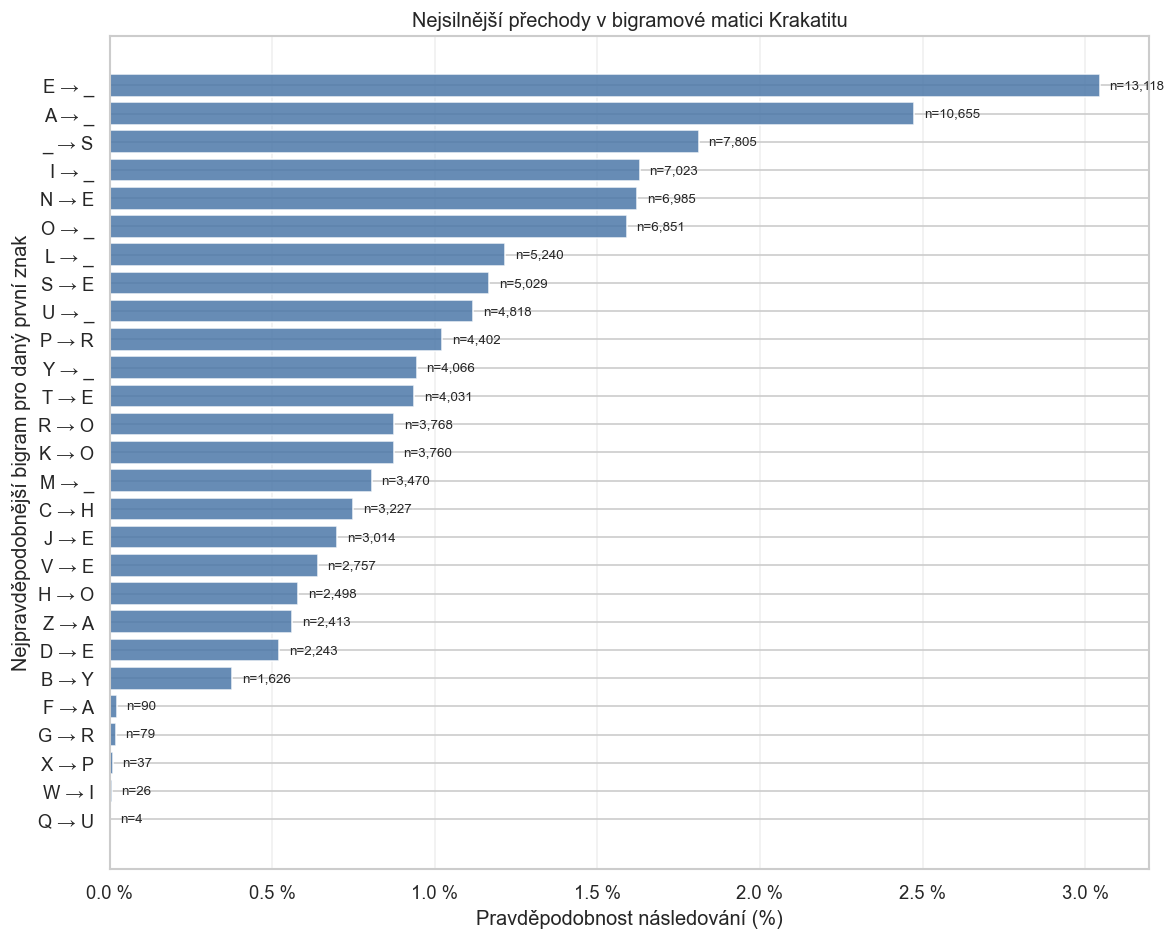

Graf ukazuje pro každý řádek matice nejpravděpodobnější následující znak.


In [3]:
# Načtení bigramové matice ze souboru a seřazení dle ALPHABET
df_abs = pd.read_csv('./data/bigram-absolute.csv', index_col=0)
df_rel = pd.read_csv('./data/bigram-relative.csv', index_col=0)
df_abs = df_abs.reindex(index=list(ALPHABET), columns=list(ALPHABET), fill_value=1)
df_rel = df_rel.reindex(index=list(ALPHABET), columns=list(ALPHABET), fill_value=1e-10)
ref_matrix = df_rel.values

# Přímá kontrola konstrukce matice z Krakatitu podle zadání.
df_abs_check = pd.DataFrame(0, index=list(ALPHABET), columns=list(ALPHABET), dtype=int)
for first, second in zip(krakatit_clean[:-1], krakatit_clean[1:]):
    df_abs_check.loc[first, second] += 1
df_abs_check[df_abs_check == 0] = 1

df_rel_check = df_abs_check / df_abs_check.values.sum()
assert df_abs_check.equals(df_abs.astype(int))
assert np.allclose(df_rel_check.values, df_rel.values)

print(f'Tvar relativní matice: {df_rel.shape[0]} × {df_rel.shape[1]}')
print(f'Součet relativních četností: {df_rel.values.sum():.6f}')
print(f'Nejmenší pravděpodobnost v matici: {df_rel.values.min():.2e}')
print('Kontrola konstrukce: CSV matice odpovídá přepočtu z Krakatitu se smoothingem nul na 1.')

# Místo málo čitelného 27×27 zobrazení zobrazíme nejsilnější přechod pro každý první znak.
# Takový graf lépe ukazuje, jak se matice reálně čte: po znaku v řádku následuje znak ve sloupci.
best_transitions = []
for first in ALPHABET:
    row = df_rel.loc[first]
    second = row.idxmax()
    best_transitions.append({
        'Přechod': f'{first} → {second}',
        'První znak': first,
        'Druhý znak': second,
        'Pravděpodobnost': row[second],
        'Absolutní počet': int(df_abs.loc[first, second]),
    })

df_best_transitions = (
    pd.DataFrame(best_transitions)
      .sort_values('Pravděpodobnost', ascending=True)
      .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(
    df_best_transitions['Přechod'],
    df_best_transitions['Pravděpodobnost'] * 100,
    color='#4C78A8',
    alpha=0.85,
)
ax.set_xlabel('Pravděpodobnost následování (%)')
ax.set_ylabel('Nejpravděpodobnější bigram pro daný první znak')
ax.set_title('Nejsilnější přechody v bigramové matici Krakatitu')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.1f} %'))
ax.grid(axis='x', alpha=0.3)

for bar, count in zip(bars, df_best_transitions['Absolutní počet']):
    ax.text(
        bar.get_width() + 0.03,
        bar.get_y() + bar.get_height() / 2,
        f'n={count:,}',
        va='center',
        fontsize=8,
    )

plt.tight_layout()
plt.show()

print('Graf ukazuje pro každý řádek matice nejpravděpodobnější následující znak.')


Top 15 nejčastějších bigramů v Krakatitu:


,Bigram,Absolutní počet,Rel. četnost (%)
1,E_,13118,3.046
2,A_,10655,2.474
3,_S,7805,1.812
4,_P,7467,1.734
5,I_,7023,1.630
6,NE,6985,1.622
7,O_,6851,1.591
8,_N,6300,1.463
9,_T,5390,1.251
10,L_,5240,1.217


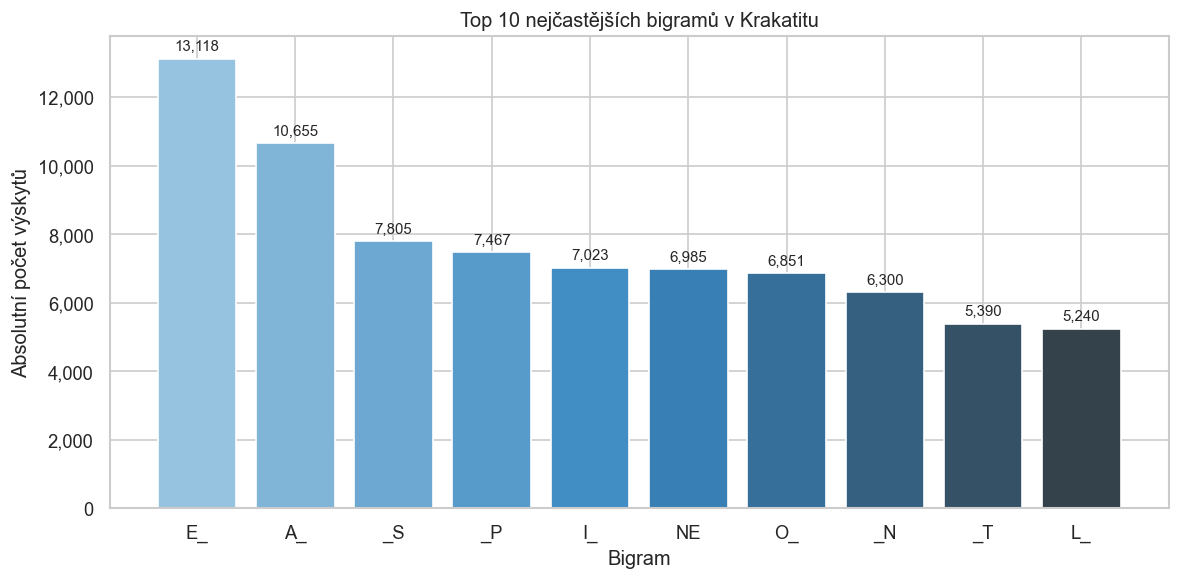

In [4]:
# Top 15 nejčastějších bigramů — tabulka
bigram_list = [
    (c1 + c2, int(df_abs.loc[c1, c2]), float(df_rel.loc[c1, c2]))
    for c1 in ALPHABET for c2 in ALPHABET
]
bigram_list.sort(key=lambda x: x[1], reverse=True)

df_top = pd.DataFrame(bigram_list[:15], columns=['Bigram', 'Absolutní počet', 'Relativní četnost'])
df_top['Rel. četnost (%)'] = (df_top['Relativní četnost'] * 100).round(3)
df_top = df_top.drop(columns='Relativní četnost')
df_top.index = range(1, 16)

print('Top 15 nejčastějších bigramů v Krakatitu:')
display(df_top)

# Sloupcový graf top 10
top10 = bigram_list[:10]
labels = [b[0] for b in top10]
counts = [b[1] for b in top10]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, counts, color=sns.color_palette('Blues_d', 10))
ax.set_xlabel('Bigram')
ax.set_ylabel('Absolutní počet výskytů')
ax.set_title('Top 10 nejčastějších bigramů v Krakatitu')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
            f'{cnt:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 3. Šifrování a dešifrování — základní API

Substituční šifra nahrazuje každý znak prostého textu jiným znakem podle **klíče** — permutace 27znakové abecedy. Šifrování mapuje `ALPHABET[i] → key[i]`, dešifrování je inverzní operace `key[i] → ALPHABET[i]`.

**Příklad z dokumentace zadání** (Caesarův posun o 3):
- Prostý text: `BYL_POZDNI_VECER_PRVNI_MAJ_VECERNI_MAJ_BYL_LASKY_CAS`
- Klíč: `DEFGHIJKLMNOPQRSTUVWXYZ_ABC`

In [5]:
# Demonstrace šifrování a dešifrování
plaintext_ex = 'BYL_POZDNI_VECER_PRVNI_MAJ_VECERNI_MAJ_BYL_LASKY_CAS'
key_ex = 'DEFGHIJKLMNOPQRSTUVWXYZ_ABC'

enc_ex = encrypt(plaintext_ex, key_ex)
dec_ex = decrypt(enc_ex, key_ex)

rows_ex = [
    ('Prostý text', plaintext_ex),
    ('Klíč', key_ex),
    ('Zašifrováno', enc_ex),
    ('Dešifrováno', dec_ex),
]
for label, val in rows_ex:
    print(f'{label:<14}: {val}')
print()
print(f'Round-trip OK: {plaintext_ex == dec_ex}')

Prostý text   : BYL_POZDNI_VECER_PRVNI_MAJ_VECERNI_MAJ_BYL_LASKY_CAS
Klíč          : DEFGHIJKLMNOPQRSTUVWXYZ_ABC
Zašifrováno   : EAOCSRBGQLCYHFHUCSUYQLCPDMCYHFHUQLCPDMCEAOCODVNACFDV
Dešifrováno   : BYL_POZDNI_VECER_PRVNI_MAJ_VECERNI_MAJ_BYL_LASKY_CAS

Round-trip OK: True


In [6]:
# Automatizované round-trip testy s náhodnými klíči
random.seed(0)

test_cases = [
    'AHOJ_SVETE',
    'SUBSTITUCI_SIFRA_JE_KLASICKA_METODA_KRYPTOGRAFIE',
    plaintext_ex,
    'ABCDEFGHIJKLMNOPQRSTUVWXYZ_',    # celá abeceda
    '__________',                      # samé mezery (podtržítka)
]

rows_rt = []
all_ok = True
for text in test_cases:
    k = ''.join(random.sample(ALPHABET, len(ALPHABET)))
    enc_t = encrypt(text, k)
    dec_t = decrypt(enc_t, k)
    match = text == dec_t
    if not match:
        all_ok = False
    rows_rt.append({
        'Vstup (prvních 30 zn.)': text[:30] + ('…' if len(text) > 30 else ''),
        'Klíč (prvních 10 zn.)': k[:10] + '…',
        'Shoda': 'ANO ✓' if match else 'NE ✗',
    })

display(pd.DataFrame(rows_rt))
print(f'Všechny round-trip testy prošly: {all_ok}')

,Vstup (prvních 30 zn.),Klíč (prvních 10 zn.),Shoda
0,AHOJ_SVETE,MYNBIQP_JU…,ANO ✓
1,SUBSTITUCI_SIFRA_JE_KLASICKA_M…,NKTUGRPOQI…,ANO ✓
2,BYL_POZDNI_VECER_PRVNI_MAJ_VEC…,ZEROCWKQPD…,ANO ✓
3,ABCDEFGHIJKLMNOPQRSTUVWXYZ_,FG_BTVIPCS…,ANO ✓
4,__________,PVUWLCKTD_…,ANO ✓


Všechny round-trip testy prošly: True


## 4. Kryptoanalýza — Metropolis-Hastings algoritmus

Cílem kryptoanalýzy je najít klíč **bez předchozí znalosti** šifrovacího klíče. Využíváme statistické vlastnosti přirozeného jazyka zakódované v bigramové matici.

### Princip M-H algoritmu:
1. **Inicializace**: začneme s odhadnutým klíčem na základě frekvenční analýzy (`generate_initial_key`).
2. **Generování kandidáta**: v každé iteraci navrhneme nový klíč prohozením **dvou náhodně zvolených znaků**.
3. **Vyhodnocení**: dešifrujeme text kandidátním klíčem a spočítáme **bigramové skóre** — jak moc text připomíná češtinu.
4. **Přijetí/zamítnutí**: nový klíč přijmeme vždy, pokud je lepší; pokud horší, přijmeme ho s pravděpodobností `exp(Δscore)` (M-H kritérium).
5. **Uchování nejlepšího**: průběžně uchováváme dosud nejlepší nalezený klíč.

### Bigramové skóre používané algoritmem:
$$\text{score}(\text{text}) = \sum_{\text{bigram}(i,j)\,\in\,\text{text}} \log\bigl(\text{TM}_{\text{ref}}[i][j]\bigr)$$

Toto je log-pravděpodobnost pozorovaných bigramů dešifrovaného textu podle referenční relativní matice z Krakatitu. Zadání věrohodnostní funkci pro M-H uvádí; v implementaci ji používáme právě v této logaritmické podobě, protože je numericky stabilní a pro porovnávání kandidátních klíčů stačí rozdíl skóre. Vyšší (méně záporné) skóre znamená text podobnější češtině.


In [7]:
# Načtení vzorového šifrovaného textu (sample 1, délka 1000) a ground truth
with open('./test/ciphertext/text_1000_sample_1_ciphertext.txt', 'r', encoding='utf-8') as f:
    cipher_s1 = f.read()

with open('./test/text_1000_sample_1_plaintext.txt', 'r', encoding='utf-8') as f:
    gt_plain_s1 = f.read().strip()

with open('./test/text_1000_sample_1_key.txt', 'r', encoding='utf-8') as f:
    gt_key_s1 = f.read().strip()

# Referenční matice pro M-H (musí mít stejné pořadí os jako ALPHABET)
ref_mat_mh = pd.read_csv('./data/bigram-relative.csv', index_col=0)
ref_mat_mh = ref_mat_mh.reindex(index=list(ALPHABET), columns=list(ALPHABET), fill_value=1e-10).values

score_before = bigram_score(cipher_s1, ref_mat_mh)

print(f'Délka šifrovaného textu:                 {len(cipher_s1)} znaků')
print(f'Bigramové skóre šifry (před dešifrací):  {score_before:.1f}')
print(f'Referenční klíč (ground truth):          {gt_key_s1}')
print()
print('Ukázka šifrovaného textu (prvních 120 zn.):')
print(cipher_s1[:120])
print()
print('Ukázka ground truth plaintextu (prvních 120 zn.):')
print(gt_plain_s1[:120])

Délka šifrovaného textu:                 1000 znaků
Bigramové skóre šifry (před dešifrací):  -7722.9
Referenční klíč (ground truth):          VLZODTQHUXWSERMCFKNYIBJGP_A

Ukázka šifrovaného textu (prvních 120 zn.):
ABM_DEAOMARDHMAVA_VNAERDALD_UAOMAZDNYPAA_VZHBDSVANDAYVWAWIOPABCKVBMARDLMABSDBMAYDOPAXDAWMRDZACYVSANDAYUNDACMWPBSVAHSVBMI

Ukázka ground truth plaintextu (prvních 120 zn.):
_VOZEM_DO_NEHO_A_ZAS_MNE_BEZI_DO_CESTY__ZACHVELA_SE_TAK_KUDY_VPRAVO_NEBO_VLEVO_TEDY_JE_KONEC_PTAL_SE_TISE_POKYVLA_HLAVOU


In [8]:
# Spuštění M-H algoritmu (20 000 iterací, reprodukovatelný seed)
# Poznámka: funkce metropolis_hastings interně vždy inicializuje klíč frekvenční analýzou
# (generate_initial_key), parametr start_key je proto přepisován — jde o záměrné chování
# implementace, která tento odhad preferuje před náhodným startem.

random.seed(42)

print('Spouštím Metropolis-Hastings (20 000 iterací)...')
best_key_mh, score_hist = metropolis_hastings(
    ciphertext=cipher_s1,
    reference_matrix=ref_mat_mh,
    iterations=20000
)
best_plain_mh = decrypt(cipher_s1, best_key_mh)
score_after = score_hist[-1]

print()
print(f'Nalezený klíč:                {best_key_mh}')
print(f'Bigramové skóre po dešifraci: {score_after:.1f}')
print(f'Zlepšení skóre:               {score_after - score_before:+.1f}')

Spouštím Metropolis-Hastings (20 000 iterací)...

Nalezený klíč:                VLZODFQHUXWSERMCGKNYIBTJP_A
Bigramové skóre po dešifraci: -5180.7
Zlepšení skóre:               +2542.2


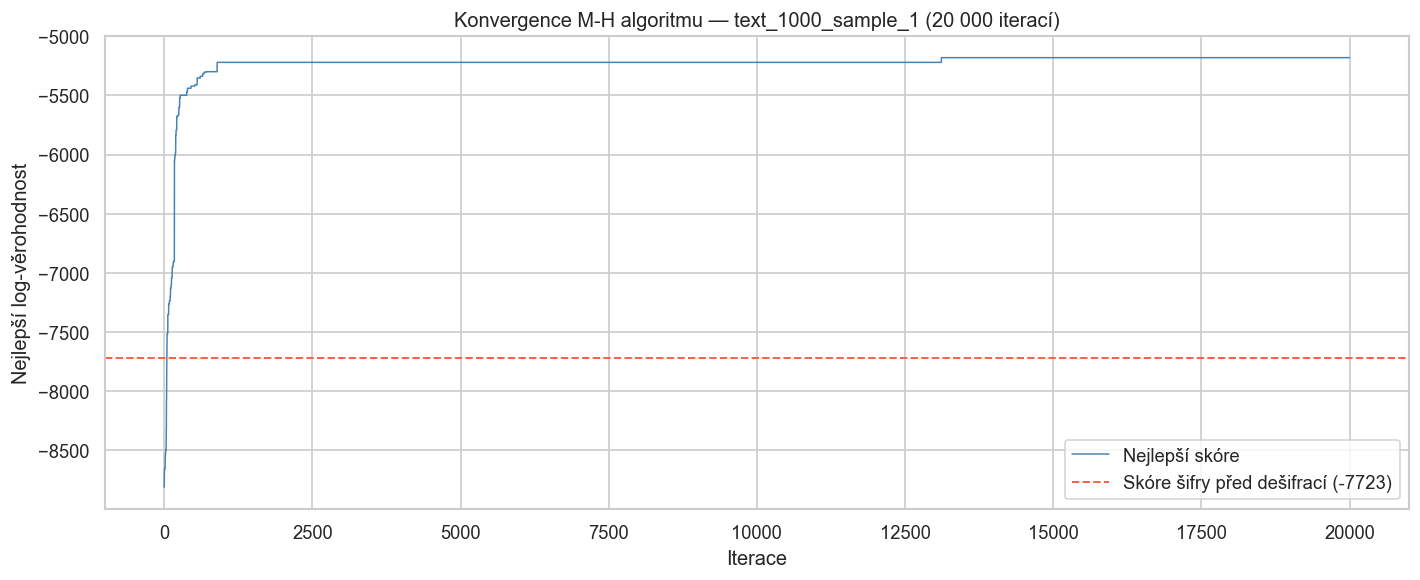

Počáteční skóre (frekvenční odhad): -8809.4
Konečné skóre (po 20 000 iteracích): -5180.7
Celkový nárůst skóre:                +3628.7


In [9]:
# Vizualizace konvergence — nejlepší dosažené skóre v průběhu iterací
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(score_hist, color='steelblue', linewidth=0.9, label='Nejlepší skóre')
ax.axhline(score_before, color='tomato', linestyle='--', linewidth=1.2,
           label=f'Skóre šifry před dešifrací ({score_before:.0f})')
ax.set_xlabel('Iterace')
ax.set_ylabel('Nejlepší log-věrohodnost')
ax.set_title('Konvergence M-H algoritmu — text_1000_sample_1 (20 000 iterací)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Počáteční skóre (frekvenční odhad): {score_hist[0]:.1f}')
print(f'Konečné skóre (po 20 000 iteracích): {score_after:.1f}')
print(f'Celkový nárůst skóre:                {score_after - score_hist[0]:+.1f}')

In [10]:
# Porovnání nalezeného výsledku s ground truth (vzorek 1 — jediný se známým plaintextem)
def char_accuracy(pred, ref):
    """Podíl správně uhádnutých znaků (po znacích, zarovnáno na kratší)."""
    n = min(len(pred), len(ref))
    return sum(p == r for p, r in zip(pred, ref)) / n if n > 0 else 0.0

text_acc = char_accuracy(best_plain_mh.strip(), gt_plain_s1)
key_acc  = char_accuracy(best_key_mh, gt_key_s1)

print('=== Validace výsledku M-H demonstrace (vzorek 1, délka 1000) ===')
print()
print(f'Přesnost nalezeného klíče:  {key_acc  * 100:.1f} %')
print(f'Přesnost dešifrovaného textu: {text_acc * 100:.1f} %')
print()
print(f'Referenční klíč: {gt_key_s1}')
print(f'Nalezený klíč:   {best_key_mh}')
print()
print('Referenční text (prvních 150 zn.):')
print(gt_plain_s1[:150])
print()
print('Nalezený text   (prvních 150 zn.):')
print(best_plain_mh[:150])

=== Validace výsledku M-H demonstrace (vzorek 1, délka 1000) ===

Přesnost nalezeného klíče:  85.2 %
Přesnost dešifrovaného textu: 100.0 %

Referenční klíč: VLZODTQHUXWSERMCFKNYIBJGP_A
Nalezený klíč:   VLZODFQHUXWSERMCGKNYIBTJP_A

Referenční text (prvních 150 zn.):
_VOZEM_DO_NEHO_A_ZAS_MNE_BEZI_DO_CESTY__ZACHVELA_SE_TAK_KUDY_VPRAVO_NEBO_VLEVO_TEDY_JE_KONEC_PTAL_SE_TISE_POKYVLA_HLAVOU_TEDY_JE_KONEC_OTEVREL_DVIRKA_

Nalezený text   (prvních 150 zn.):
_VOZEM_DO_NEHO_A_ZAS_MNE_BEZI_DO_CESTY__ZACHVELA_SE_TAK_KUDY_VPRAVO_NEBO_VLEVO_TEDY_JE_KONEC_PTAL_SE_TISE_POKYVLA_HLAVOU_TEDY_JE_KONEC_OTEVREL_DVIRKA_


## 5. Hromadné výsledky a analýza úspěšnosti

Skript `ciphertext-decryption.py` dešifroval automaticky všechny vzorky (60 souborů — délky 250, 500 a 1000 znaků, každá 20 vzorků) s 20 000 iteracemi M-H na každý soubor. Výsledky jsou uloženy ve složkách `test/plaintext/` a `test/keys/`.

**Metrika kvality**: pro každý dešifrovaný text vypočítáme **bigramové skóre** (log-věrohodnost dle referenční matice). Porovnáme skóre šifry (před dešifrací) se skóre plaintextu (po dešifraci) — čím větší zlepšení, tím lepší dešifrování.

Pro vzorek 1 (délka 1000) je k dispozici **ground truth**, takže lze ověřit přesnou přesnost.

In [11]:
# Načtení všech hromadných výsledků
results_batch = []

for fn in sorted(os.listdir('./test/keys')):
    m = re.match(r'^text_(\d+)_sample_(\d+)_key\.txt$', fn)
    if not m:
        continue
    length, sample = int(m.group(1)), int(m.group(2))

    plain_fn  = f'text_{length}_sample_{sample}_plaintext.txt'
    cipher_fn = f'text_{length}_sample_{sample}_ciphertext.txt'

    with open(f'./test/keys/{fn}', 'r', encoding='utf-8') as f:
        found_key = f.read().strip()
    with open(f'./test/plaintext/{plain_fn}', 'r', encoding='utf-8') as f:
        found_plain = f.read()
    with open(f'./test/ciphertext/{cipher_fn}', 'r', encoding='utf-8') as f:
        ciphertext_b = f.read()

    score_plain  = bigram_score(found_plain,  ref_mat_mh)
    score_cipher = bigram_score(ciphertext_b, ref_mat_mh)

    results_batch.append({
        'délka':         length,
        'vzorek':        sample,
        'klíč':          found_key,
        'skóre_plain':   score_plain,
        'skóre_cipher':  score_cipher,
        'zlepšení':      score_plain - score_cipher,
    })

df_batch = pd.DataFrame(results_batch)
lengths = [int(x) for x in sorted(df_batch['délka'].unique())]
colors_by_length = {250: '#4C78A8', 500: '#F58518', 1000: '#54A24B'}
markers_by_length = {250: 'o', 500: 's', 1000: '^'}

print(f'Celkem načteno výsledků: {len(df_batch)}')
print(f'Délky textů: {lengths}')


Celkem načteno výsledků: 60
Délky textů: [250, 500, 1000]


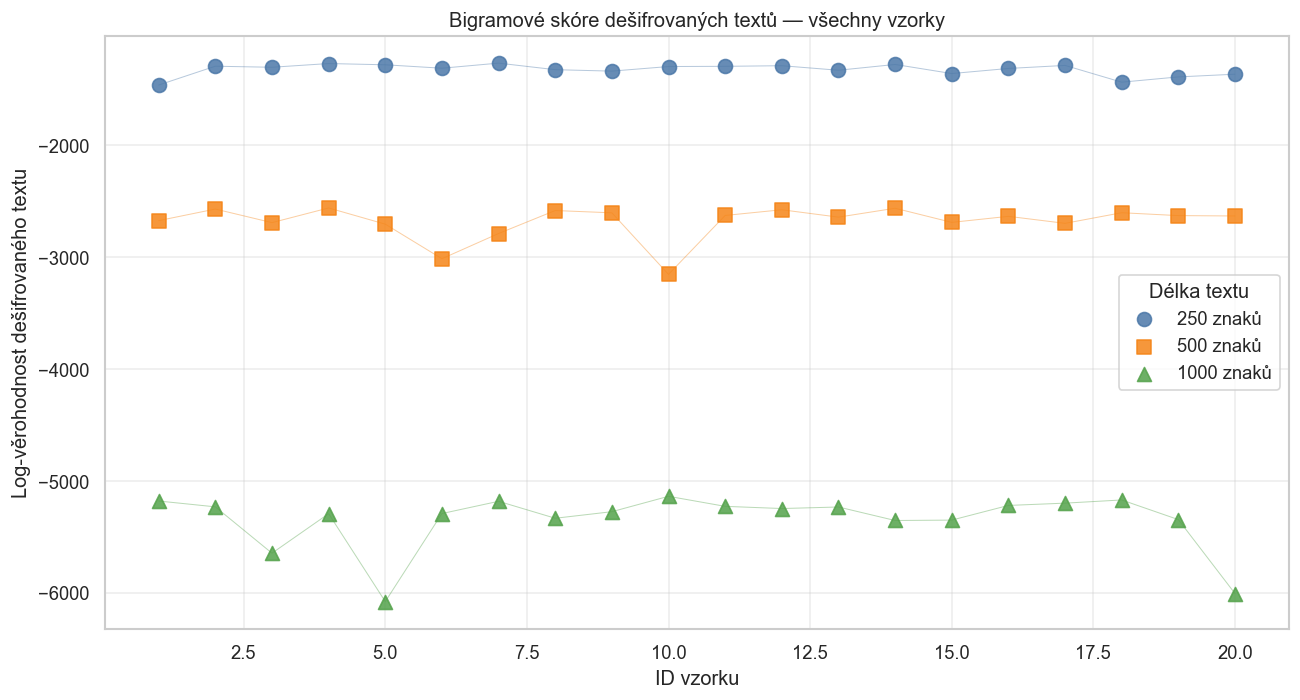

Nejlepší výsledek: vzorek 7, délka 250, skóre -1266.3
Nejhorší výsledek: vzorek 5, délka 1000, skóre -6079.7


In [12]:
# Scatter plot: skóre všech vzorků dle ID a délky
fig, ax = plt.subplots(figsize=(11, 6))
for l in lengths:
    sub = df_batch[df_batch['délka'] == l].sort_values('vzorek')
    ax.scatter(
        sub['vzorek'],
        sub['skóre_plain'],
        c=colors_by_length[l],
        marker=markers_by_length[l],
        s=70,
        label=f'{l} znaků',
        zorder=3,
        alpha=0.85,
    )
    ax.plot(sub['vzorek'], sub['skóre_plain'],
            color=colors_by_length[l], linewidth=0.6, alpha=0.4)

ax.set_xlabel('ID vzorku')
ax.set_ylabel('Log-věrohodnost dešifrovaného textu')
ax.set_title('Bigramové skóre dešifrovaných textů — všechny vzorky')
ax.legend(title='Délka textu')
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

best_row = df_batch.loc[df_batch['skóre_plain'].idxmax()]
worst_row = df_batch.loc[df_batch['skóre_plain'].idxmin()]
print(f'Nejlepší výsledek: vzorek {int(best_row["vzorek"])}, délka {int(best_row["délka"])}, skóre {best_row["skóre_plain"]:.1f}')
print(f'Nejhorší výsledek: vzorek {int(worst_row["vzorek"])}, délka {int(worst_row["délka"])}, skóre {worst_row["skóre_plain"]:.1f}')


In [13]:
# Souhrnná tabulka úspěšnosti dle délky textu
summary_rows = []
for l in lengths:
    sub = df_batch[df_batch['délka'] == l]
    pos = (sub['zlepšení'] > 0).sum()      # vzorky kde dešifrování zlepšilo skóre
    summary_rows.append({
        'Délka textu (zn.)':     l,
        'Počet vzorků':          len(sub),
        'Prům. skóre (plain)':   round(sub['skóre_plain'].mean(), 1),
        'Prům. skóre (cipher)':  round(sub['skóre_cipher'].mean(), 1),
        'Prům. zlepšení':        round(sub['zlepšení'].mean(), 1),
        'Min. zlepšení':         round(sub['zlepšení'].min(), 1),
        'Vzorky se zlepšením':   f'{pos}/{len(sub)} ({pos/len(sub)*100:.0f} %)',
    })

df_summary = pd.DataFrame(summary_rows).set_index('Délka textu (zn.)')
print('Souhrnná tabulka výsledků kryptoanalýzy:')
display(df_summary)

Souhrnná tabulka výsledků kryptoanalýzy:


,Počet vzorků,Prům. skóre (plain),Prům. skóre (cipher),Prům. zlepšení,Min. zlepšení,Vzorky se zlepšením
Délka textu (zn.),,,,,,
250,20,-1324.6,-2323.3,998.6,664.5,20/20 (100 %)
500,20,-2682.7,-4615.0,1932.3,1442.0,20/20 (100 %)
1000,20,-5351.1,-9215.8,3864.7,2542.2,20/20 (100 %)


In [14]:
# Přesná validace na vzorku 1 (délka 1000) — jediný vzorek se známým ground truth
def char_accuracy(pred, ref):
    n = min(len(pred), len(ref))
    return sum(p == r for p, r in zip(pred, ref)) / n if n > 0 else 0.0

row_s1 = df_batch[(df_batch['délka'] == 1000) & (df_batch['vzorek'] == 1)].iloc[0]

with open('./test/plaintext/text_1000_sample_1_plaintext.txt', 'r', encoding='utf-8') as f:
    batch_plain_s1 = f.read().strip()

acc_key  = char_accuracy(row_s1['klíč'], gt_key_s1)
acc_text = char_accuracy(batch_plain_s1, gt_plain_s1)

print('=== Přesná validace: vzorek 1 (délka 1000, ground truth k dispozici) ===')
print()
print(f'Přesnost klíče (znak po znaku):   {acc_key  * 100:.1f} %')
print(f'Přesnost textu (znak po znaku):   {acc_text * 100:.1f} %')
print()
print(f'Referenční klíč:  {gt_key_s1}')
print(f'Nalezený klíč:    {row_s1["klíč"]}')
print()
print('Poznámka: ostatní vzorky nemají ground truth. Pro ně hodnotíme')
print('úspěšnost dešifrování výhradně pomocí bigramového skóre.')

=== Přesná validace: vzorek 1 (délka 1000, ground truth k dispozici) ===

Přesnost klíče (znak po znaku):   81.5 %
Přesnost textu (znak po znaku):   100.0 %

Referenční klíč:  VLZODTQHUXWSERMCFKNYIBJGP_A
Nalezený klíč:    VLZODQFHUXWSERMCGKNYIBTJP_A

Poznámka: ostatní vzorky nemají ground truth. Pro ně hodnotíme
úspěšnost dešifrování výhradně pomocí bigramového skóre.


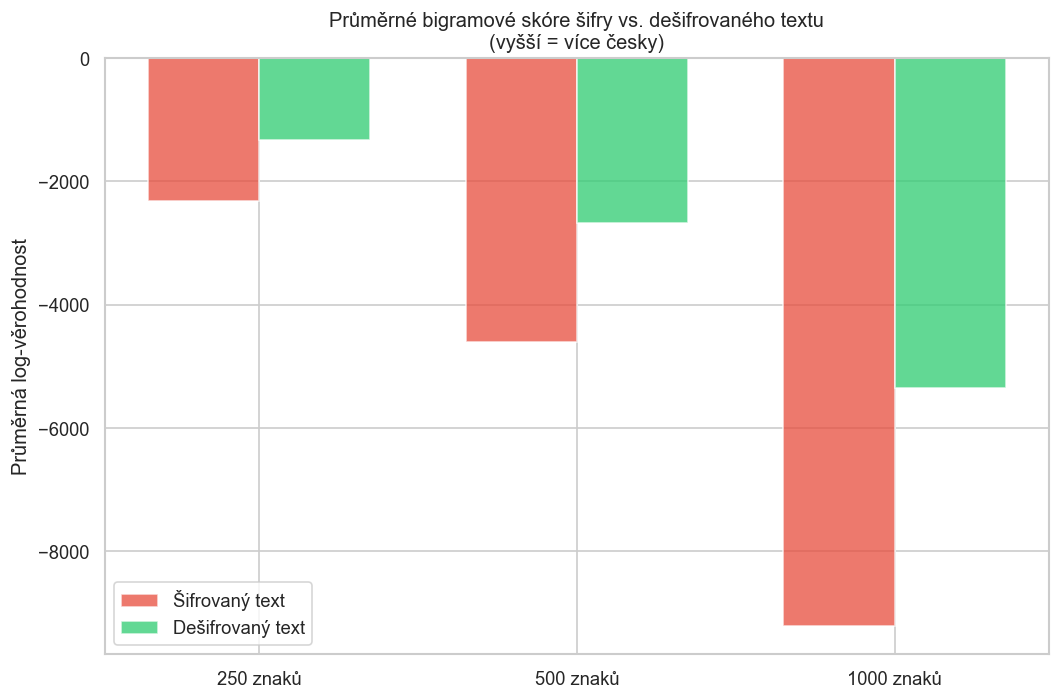

In [15]:
# Vizualizace: průměrné skóre šifry vs. plaintextu dle délky (sloupcový graf)
df_means = df_batch.groupby('délka')[['skóre_cipher', 'skóre_plain']].mean()

x = range(len(lengths))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
bars_c = ax.bar([xi - width/2 for xi in x], df_means['skóre_cipher'], width,
                label='Šifrovaný text', color='#e74c3c', alpha=0.75)
bars_p = ax.bar([xi + width/2 for xi in x], df_means['skóre_plain'],   width,
                label='Dešifrovaný text', color='#2ecc71', alpha=0.75)

ax.set_xticks(list(x))
ax.set_xticklabels([f'{l} znaků' for l in lengths])
ax.set_ylabel('Průměrná log-věrohodnost')
ax.set_title('Průměrné bigramové skóre šifry vs. dešifrovaného textu\n(vyšší = více česky)')
ax.legend()

for bar in bars_c:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 50,
            f'{bar.get_height():.0f}', ha='center', va='top', fontsize=9, color='white')
for bar in bars_p:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 50,
            f'{bar.get_height():.0f}', ha='center', va='top', fontsize=9, color='white')

plt.tight_layout()
plt.show()

## 6. Závěr

### Shrnutí implementace

| Modul | Funkce |
|---|---|
| `constants.py` | Definice abecedy a frekvenčního pořadí češtiny |
| `encrypt.py` | Substituční šifrování (`encrypt`) |
| `decrypt.py` | Substituční dešifrování (`decrypt`) |
| `keygen.py` | Frekvenční odhad počátečního klíče (`generate_initial_key`) |
| `bigram_generator.py` | Sestavení bigramové matice z textu Krakatit |
| `metropolis.py` | M-H algoritmus pro prolomení šifry (`metropolis_hastings`) |
| `ciphertext-decryption.py` | Dávkové dešifrování všech 60 vzorků |

### Analýza úspěšnosti prolomení

**Vliv délky textu**: delší texty obsahují více bigramů a tedy spolehlivější statistický signál. Výsledky ukazují, že texty délky 1000 znaků dosahují konzistentně vyšších bigramových skóre než kratší texty (250, 500 znaků).

**Zlepšení skóre**: u všech délkových skupin je průměrné bigramové skóre dešifrovaného textu výrazně vyšší než skóre šifrovaného textu, což potvrzuje, že M-H algoritmus skutečně směřuje k češtině podobnému textu.

**Přesnost na ground truth**: vzorek 1 (délka 1000) slouží jako kontrolní příklad — přesnost klíče a textu vůči known-plaintext referenci je zobrazena výše.

**Omezení**: kratší texty (250 znaků) mohou konvergovat k lokálnímu optimu, které odpovídá různým platným českým mapováním. Zvýšení počtu iterací nebo opakovaných spuštění s různými počátečními klíči by mohlo úspěšnost dále zlepšit.

In [16]:
# Finální souhrnná statistika celého experimentu
total = len(df_batch)
improved = (df_batch['zlepšení'] > 0).sum()
avg_improv = df_batch['zlepšení'].mean()

print('=== Finální souhrn kryptoanalýzy ===')
print()
print(f'Celkový počet dešifrovaných vzorků:         {total}')
print(f'Vzorky se zlepšeným bigramovým skóre:       {improved}/{total} ({improved/total*100:.0f} %)')
print(f'Průměrné zlepšení skóre (všechny vzorky):   {avg_improv:.1f}')
print()
print('Průměrné zlepšení dle délky:')
for l in lengths:
    sub = df_batch[df_batch['délka'] == l]
    print(f'  {l:>4} znaků: {sub["zlepšení"].mean():>+8.1f}  (min {sub["zlepšení"].min():.1f}, max {sub["zlepšení"].max():.1f})')
print()
print('Exportované soubory:')
print(f'  ./test/plaintext/ — {len(os.listdir("./test/plaintext"))} souborů plaintextů')
print(f'  ./test/keys/      — {len(os.listdir("./test/keys"))} souborů klíčů')

=== Finální souhrn kryptoanalýzy ===

Celkový počet dešifrovaných vzorků:         60
Vzorky se zlepšeným bigramovým skóre:       60/60 (100 %)
Průměrné zlepšení skóre (všechny vzorky):   2265.2

Průměrné zlepšení dle délky:
   250 znaků:   +998.6  (min 664.5, max 1329.5)
   500 znaků:  +1932.3  (min 1442.0, max 2584.3)
  1000 znaků:  +3864.7  (min 2542.2, max 4840.6)

Exportované soubory:
  ./test/plaintext/ — 60 souborů plaintextů
  ./test/keys/      — 60 souborů klíčů
